# Hyperparameter search

This notebook contains the hyperparameter search of the Appellian Neural Network (ANNet) for the double pendulum and the analysis of its trials. The search uses one synthetic dataset of 10,000 samples and 500 Optuna trials.

**1. Appell acceleration energy.** `SymPy` derives the Appell acceleration energy $S$ of the double pendulum and the joint torques $\tau = \partial S / \partial \ddot{q}$. Both expressions are converted to `NumPy` functions that provide the ground truth.

**2. Dataset.** Joint angles, velocities and accelerations are sampled uniformly ($q$ within $\pm\pi/2$ rad, $\dot{q}$ within $\pm 5$ rad/s, $\ddot{q}$ within $\pm 20$ rad/s$^2$) with seed 22, and the torques are computed analytically. The inputs are normalized. The first 80 % of the samples (8,000) are used for training and the last 20 % (2,000) for validation.

**3. Search space and objective.** Each trial builds a fully connected network with 1 to 10 hidden layers, 1 to 256 nodes per layer and one activation function (GELU, Tanh, Softplus, ELU or ReLU). The network is trained with Adam for 100 epochs at a batch size of 64 and a learning rate between $10^{-8}$ and $10^{-1}$ (log-uniform). The network outputs the scalar $S$, `torch.autograd` differentiates it with respect to $\ddot{q}$ to obtain the torque, and the loss is the mean squared torque error. The objective of the search is the validation loss after the last epoch.

**4. Search.** Optuna runs 500 trials with the tree-structured Parzen estimator sampler (seed 22) and the median pruner (ten warm-up epochs). When `optuna_study.pkl` is present in the notebook folder, the stored study is loaded and the search is skipped. Otherwise the search runs and writes `optuna_study.pkl` (study object), `optuna_search_results.csv` (one row per trial) and `best_hyperparameters.json` (parameters of the best trial). A repeated search can return trial values that differ from the stored study, because the result of network training can depend on the software and hardware environment.

**5. Figures.** Torque RMSE by activation function, fANOVA sensitivity of the validation loss to the hyperparameters, and torque RMSE against learning rate, network depth and layer width. The figures are shown inline and saved as SVG files in `hyperparameter_figures/`.

In [1]:
import sympy as sp
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.autograd as autograd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import random
import optuna
import joblib
import json
import pandas as pd
from optuna.importance import get_param_importances, FanovaImportanceEvaluator

In [2]:
# Configuration
SEED = 22
N_SAMPLES = 10_000   # size of the search dataset (80 % training, 20 % validation)
BATCH_SIZE = 64
N_TRIALS = 500
PARAMS = {'m1': 1.0, 'm2': 1.0, 'l1': 1.0, 'l2': 1.0}

# Results files of the search
STUDY_FILE = "optuna_study.pkl"
RESULTS_FILE = "optuna_search_results.csv"
BEST_FILE = "best_hyperparameters.json"

# Folder for the figures
FIGURE_DIR = "hyperparameter_figures"
os.makedirs(FIGURE_DIR, exist_ok=True)

## 1. Appell acceleration energy

In [3]:
# 1. Define Time and Parameters
t = sp.symbols('t')
m1, m2, l1, l2, g = sp.symbols('m1 m2 l1 l2 g')
theta1 = sp.Function('theta1')(t)
theta2 = sp.Function('theta2')(t)

# 2. Shorthand for derivatives
q1, q2 = sp.symbols('q1 q2')
dq1, dq2 = sp.symbols('dq1 dq2')
ddq1, ddq2 = sp.symbols('ddq1 ddq2')

# 3. Kinematics
x1 = l1 * sp.sin(theta1)
y1 = -l1 * sp.cos(theta1)
x2 = x1 + l2 * sp.sin(theta1 + theta2)
y2 = y1 - l2 * sp.cos(theta1 + theta2)

# Velocities
vx1, vy1 = sp.diff(x1, t), sp.diff(y1, t)
vx2, vy2 = sp.diff(x2, t), sp.diff(y2, t)

# Accelerations
ax1, ay1 = sp.diff(vx1, t), sp.diff(vy1, t)
ax2, ay2 = sp.diff(vx2, t), sp.diff(vy2, t)

# 4. Gibbs-Appell Function S
accel_mag_sq_1 = ax1**2 + ay1**2
accel_mag_sq_2 = ax2**2 + ay2**2
S_symbolic = 0.5 * m1 * accel_mag_sq_1 + 0.5 * m2 * accel_mag_sq_2

# Substitution map to clean symbols
subs_map = {
    theta1.diff(t, t): ddq1, theta2.diff(t, t): ddq2,
    theta1.diff(t): dq1, theta2.diff(t): dq2,
    theta1: q1, theta2: q2
}
S_clean = S_symbolic.subs(subs_map).simplify()

# Forces (Derivatives of S w.r.t acceleration)
tau1_sym = sp.diff(S_clean, ddq1)
tau2_sym = sp.diff(S_clean, ddq2)

# Create Fast Lambdified Functions
compute_S_ground_truth = sp.lambdify(
    (q1, q2, dq1, dq2, ddq1, ddq2, m1, m2, l1, l2), S_clean, 'numpy'
)
compute_tau_ground_truth = sp.lambdify(
    (q1, q2, dq1, dq2, ddq1, ddq2, m1, m2, l1, l2), [tau1_sym, tau2_sym], 'numpy'
)

print("Physics engine initialized.")

Physics engine initialized.


## 2. Dataset

In [4]:
def seed_everything(seed=27):
    # 1. Python standard library
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

    # 2. NumPy (Data generation)
    np.random.seed(seed)

    # 3. PyTorch (Model weights & shuffling)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) # For multi-GPU

    # 4. Force deterministic algorithms (Crucial for reproducibility)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [5]:
def generate_data(n_samples):
    q = np.random.uniform(-np.pi/2, np.pi/2, (n_samples, 2))
    dq = np.random.uniform(-5.0, 5.0, (n_samples, 2))
    ddq = np.random.uniform(-20.0, 20.0, (n_samples, 2))

    # Compute S
    S_values = compute_S_ground_truth(
        q[:, 0], q[:, 1], dq[:, 0], dq[:, 1], ddq[:, 0], ddq[:, 1],
        PARAMS['m1'], PARAMS['m2'], PARAMS['l1'], PARAMS['l2']
    )

    # Compute Forces
    tau_values = compute_tau_ground_truth(
        q[:, 0], q[:, 1], dq[:, 0], dq[:, 1], ddq[:, 0], ddq[:, 1],
        PARAMS['m1'], PARAMS['m2'], PARAMS['l1'], PARAMS['l2']
    )
    tau_values = np.array(tau_values).T

    X = np.hstack([q, dq, ddq])
    return X.astype(np.float32), S_values.reshape(-1, 1).astype(np.float32), tau_values.astype(np.float32)


def prepare_dataset(dataset_size):
    seed_everything(seed=SEED)

    # Generate Data
    X_full, S_full, tau_full = generate_data(dataset_size)

    # Normalization & Scaling
    X_mean = X_full.mean(axis=0)
    X_std = X_full.std(axis=0)
    S_mean = S_full.mean()
    S_std = S_full.std()

    X_norm = (X_full - X_mean) / (X_std + 1e-8)
    S_norm = (S_full - S_mean) / (S_std + 1e-8)

    # Chain Rule Scaling Factors
    ddq_std = X_std[4:6]
    chain_rule_scale = S_std / (ddq_std + 1e-8)

    # Split Train/Test
    split_idx = int(dataset_size * 0.8)

    return {
        "dataset_size": dataset_size,
        "X_full": X_full,
        "S_full": S_full,
        "tau_full": tau_full,
        "X_mean": X_mean,
        "X_std": X_std,
        "S_mean": S_mean,
        "S_std": S_std,
        "X_norm": X_norm,
        "S_norm": S_norm,
        "chain_rule_scale": chain_rule_scale,
        "X_train": torch.tensor(X_norm[:split_idx]),
        "tau_train": torch.tensor(tau_full[:split_idx]),
        "X_test": torch.tensor(X_norm[split_idx:]),
        "tau_test": torch.tensor(tau_full[split_idx:]),
    }


# Dataset of the search. The objective function reads these variables during each trial.
dataset = prepare_dataset(N_SAMPLES)
X_train = dataset["X_train"]
tau_train = dataset["tau_train"]
X_test = dataset["X_test"]
tau_test = dataset["tau_test"]
chain_rule_scale = dataset["chain_rule_scale"]

print(f"Dataset of {N_SAMPLES:,} samples ready ({len(X_train):,} training, {len(X_test):,} validation).")

Dataset of 10,000 samples ready (8,000 training, 2,000 validation).


## 3. Search space and objective

In [6]:
# 1. Dynamic Model Builder (Optuna-driven)
def build_model(trial):
    n_layers = trial.suggest_int("n_layers", 1, 10)

    # Select the activation function for this trial
    activation_name = trial.suggest_categorical("activation", ["GELU", "Tanh", "Softplus", "ELU", "ReLU"])

    layers = []
    in_features = 6 # [q, dq, ddq]

    for i in range(n_layers):
        out_features = trial.suggest_int(f"n_units_l{i}", 1, 256)
        layers.append(nn.Linear(in_features, out_features))

        # Instantiate the chosen activation class dynamically
        layers.append(getattr(nn, activation_name)())


        in_features = out_features

    layers.append(nn.Linear(in_features, 1)) # Output S
    return nn.Sequential(*layers)

# 2. Physics Loss Function
def compute_force_loss_chain_rule(model, X_batch, tau_batch_real, chain_scale):
    # Enable grad for input derivative (dS/dq)
    X_batch_grad = X_batch.clone().requires_grad_(True)

    S_pred_norm = model(X_batch_grad)
    S_sum = S_pred_norm.sum()

    # Calculate gradient of S w.r.t input
    grads_norm = autograd.grad(S_sum, X_batch_grad, create_graph=True)[0]

    dS_dddq_norm = grads_norm[:, 4:6]

    if not isinstance(chain_scale, torch.Tensor):
        chain_scale = torch.tensor(chain_scale, dtype=torch.float32, device=X_batch.device)

    tau_pred_real = dS_dddq_norm * chain_scale
    loss = torch.mean((tau_pred_real - tau_batch_real) ** 2)
    return loss

# 3. Optimization Loop
def objective(trial):
    model = build_model(trial)

    lr = trial.suggest_float("lr", 1e-8, 1e-1, log=True)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    SEARCH_EPOCHS = 100

    for epoch in range(SEARCH_EPOCHS):
        model.train()
        indices = torch.randperm(X_train.shape[0])

        for start_idx in range(0, X_train.shape[0], BATCH_SIZE):
            end_idx = min(start_idx + BATCH_SIZE, X_train.shape[0])
            batch_indices = indices[start_idx:end_idx]

            X_batch = X_train[batch_indices]
            tau_batch = tau_train[batch_indices]

            optimizer.zero_grad()
            loss = compute_force_loss_chain_rule(model, X_batch, tau_batch, chain_rule_scale)
            loss.backward()
            optimizer.step()

        # --- Validation ---
        model.eval()
        # No 'with torch.no_grad()' because the loss needs the derivatives
        val_loss = compute_force_loss_chain_rule(model, X_test, tau_test, chain_rule_scale)

        trial.report(val_loss.item(), epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return val_loss.item()

## 4. Search

The stored study is loaded when `optuna_study.pkl` is present. To run a new search, remove or rename that file first.

In [7]:
if os.path.exists(STUDY_FILE):
    study = joblib.load(STUDY_FILE)
    fresh_search = False
    print(f"Found existing study: '{STUDY_FILE}'. Skipping the search and loading its {len(study.trials)} trials.")
else:
    print(f"'{STUDY_FILE}' not found. Starting a search of {N_TRIALS} trials with seed {SEED}...")

    # Sampler and pruner
    seed_everything(SEED)
    sampler = optuna.samplers.TPESampler(seed=SEED)
    pruner = optuna.pruners.MedianPruner(n_warmup_steps=10)

    study = optuna.create_study(direction="minimize", sampler=sampler, pruner=pruner)
    study.optimize(objective, n_trials=N_TRIALS)
    fresh_search = True

Found existing study: 'optuna_study.pkl'. Skipping the search and loading its 500 trials.


In [8]:
pruned_trials = [t for t in study.trials if t.state == optuna.trial.TrialState.PRUNED]
complete_trials = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]

print("Study statistics")
print(f"  Total trials:     {len(study.trials)}")
print(f"  Complete trials:  {len(complete_trials)}")
print(f"  Pruned trials:    {len(pruned_trials)}")

Study statistics
  Total trials:     500
  Complete trials:  181
  Pruned trials:    319


In [9]:
# Best trial
best_mse = study.best_trial.value
best_rmse = np.sqrt(best_mse)
print(f"Best trial:    {study.best_trial.number}")
print(f"Best MSE loss: {best_mse:.6f}")
print(f"Best RMSE:     {best_rmse:.6f} (N m)")

print("Best parameters")
for key, value in study.best_trial.params.items():
    print(f"  {key}: {value}")

# Trial table. Optuna stores the validation loss in the column "value".
df_results = study.trials_dataframe()
df_results["RMSE"] = np.sqrt(df_results["value"])

# The results files are written only after a new search
if fresh_search:
    df_results.to_csv(RESULTS_FILE, index=False)
    joblib.dump(study, STUDY_FILE)
    with open(BEST_FILE, "w") as f:
        json.dump(study.best_trial.params, f, indent=4)
    print(f"Saved '{RESULTS_FILE}', '{STUDY_FILE}' and '{BEST_FILE}'.")
else:
    print("The study was loaded from file. The results files were not rewritten.")

# Five best trials
df_results.sort_values("RMSE").head(5)[
    ["number", "state", "RMSE", "params_n_layers", "params_activation", "params_lr"]
]

Best trial:    220
Best MSE loss: 0.046823
Best RMSE:     0.216387 (N m)
Best parameters
  n_layers: 4
  activation: GELU
  n_units_l0: 225
  n_units_l1: 61
  n_units_l2: 91
  n_units_l3: 99
  lr: 0.0011316535454287552
The study was loaded from file. The results files were not rewritten.


,number,state,RMSE,params_n_layers,params_activation,params_lr
220,220,COMPLETE,0.216387,4,GELU,0.001132
85,85,COMPLETE,0.239816,3,GELU,0.001359
202,202,COMPLETE,0.240334,4,GELU,0.000996
395,395,COMPLETE,0.261449,7,GELU,0.001318
453,453,COMPLETE,0.264017,4,GELU,0.003787


## 5. Figures

The figures use the study object and the trial table of the cells above.

Saved 'hyperparameter_figures/activation_search.svg'


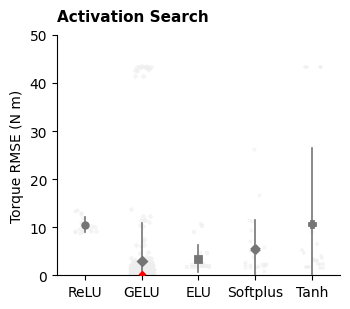

In [10]:
plt.rcParams['svg.fonttype'] = 'none'

fig, ax = plt.subplots(figsize=(3.6, 3.2))

# Data
df_plot = df_results.rename(columns={"params_activation": "Activation", "value": "Loss"})

order = ["ReLU", "GELU", "ELU", "Softplus", "Tanh"]
markers = {"ReLU": "o", "GELU": "D", "ELU": "s", "Softplus": "X", "Tanh": "P"}

# Best trial
best_idx = df_plot["RMSE"].idxmin()
df_best = df_plot.loc[[best_idx]]
optimal_activation = df_best["Activation"].values[0]

# All trials in the background, one marker shape per activation
for act in order:
    subset = df_plot[df_plot["Activation"] == act]
    if subset.empty:
        continue
    sns.stripplot(
        x="Activation",
        y="RMSE",
        data=subset,
        order=order,
        color="#EEEEEE",
        marker=markers[act],
        size=3,
        jitter=0.2,
        alpha=0.6,
        zorder=0,
        legend=False,
        ax=ax
    )

# Best trial in red
sns.stripplot(
    x="Activation",
    y="RMSE",
    data=df_best,
    order=order,
    color="red",
    marker=markers[optimal_activation],
    size=4,
    jitter=0,
    alpha=1.0,
    zorder=20,
    legend=False,
    ax=ax
)

# Mean and standard deviation per activation
point_palette = {act: "#757575" for act in order}
marker_list = [markers[act] for act in order]

sns.pointplot(
    x="Activation",
    y="RMSE",
    hue="Activation",
    data=df_plot,
    order=order,
    hue_order=order,
    palette=point_palette,
    markers=marker_list,
    errorbar='sd',
    capsize=0,
    linestyle='none',
    markersize=4,
    err_kws={'linewidth': 1.2},
    zorder=10,
    legend=False,
    ax=ax
)

# Axes
ax.spines[['top', 'right']].set_visible(False)
ax.set_title("Activation Search", loc='left', pad=10, fontweight='bold', fontsize=11)
ax.set_ylabel("Torque RMSE (N m)")
ax.set_xlabel("")

ax.set_yscale("linear")
ax.set_ylim(0, 50)

plt.tight_layout()
figure_path = os.path.join(FIGURE_DIR, "activation_search.svg")
plt.savefig(figure_path, format="svg")
print(f"Saved '{figure_path}'")
plt.show()

# Comp. Units (Layer 0)   51.4%
Learning Rate             25.5%
Network Depth             18.3%
Activation                 4.8%
Saved 'hyperparameter_figures/hyperparameter_sensitivity.svg'


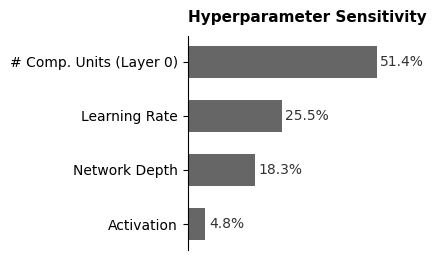

In [11]:
plt.rcParams['svg.fonttype'] = 'none'

label_map = {
    "lr":          "Learning Rate",
    "n_layers":    "Network Depth",
    "n_units_l0":  "# Comp. Units (Layer 0)",
    "activation":  "Activation",
}

# fANOVA importance of the hyperparameters that are present in every trial.
# The seed fixes the random forest of the evaluator.
evaluator = FanovaImportanceEvaluator(seed=SEED)
importances = get_param_importances(study, evaluator=evaluator)

for name, value in importances.items():
    print(f"{label_map.get(name, name):<24} {value:6.1%}")

fig, ax = plt.subplots(figsize=(4.4, 2.7))

clean_labels = [label_map.get(k, k) for k in importances.keys()]
values = list(importances.values())

# Largest bar at the top
sorted_indices = np.argsort(values)
clean_labels = [clean_labels[i] for i in sorted_indices]
values = [values[i] for i in sorted_indices]

bars = ax.barh(clean_labels, values, color="#666666", height=0.6)

# Percentages
for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.01,
        bar.get_y() + bar.get_height()/2,
        f'{width:.1%}',
        va='center',
        fontsize=10,
        color="#333333"
    )

# Axes
ax.spines[['top', 'right', 'bottom']].set_visible(False)
ax.set_xticks([])
ax.set_title("Hyperparameter Sensitivity", loc='left', pad=10, fontweight='bold', fontsize=11)

plt.tight_layout()
figure_path = os.path.join(FIGURE_DIR, "hyperparameter_sensitivity.svg")
plt.savefig(figure_path, format="svg")
print(f"Saved '{figure_path}'")
plt.show()

Saved 'hyperparameter_figures/hyperparameter_landscapes.svg'


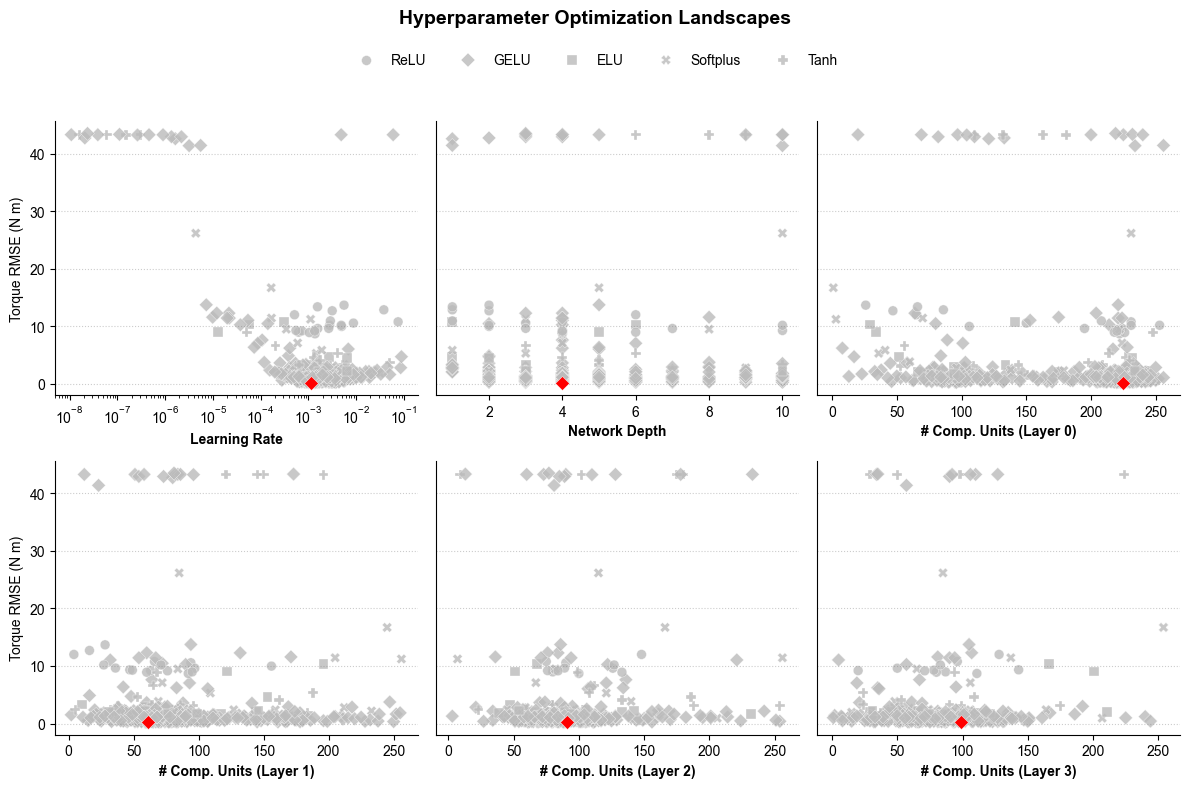

In [12]:
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']

# Data
param_map = {
    "params_lr":          "Learning Rate",
    "params_n_units_l0":  "# Comp. Units (Layer 0)",
    "params_n_units_l1":  "# Comp. Units (Layer 1)",
    "params_n_units_l2":  "# Comp. Units (Layer 2)",
    "params_n_units_l3":  "# Comp. Units (Layer 3)",
    "params_n_layers":    "Network Depth",
    "params_activation":  "Activation",
    "value":              "Loss"
}
df_plot = df_results.rename(columns=param_map)

params_to_plot = [
    "Learning Rate", "Network Depth",
    "# Comp. Units (Layer 0)", "# Comp. Units (Layer 1)",
    "# Comp. Units (Layer 2)", "# Comp. Units (Layer 3)"
]

# Best trial
best_idx = df_plot["RMSE"].idxmin()
df_best = df_plot.loc[[best_idx]]

# Two rows of three panels, one panel per hyperparameter
fig, axes = plt.subplots(2, 3, figsize=(12, 8), sharey=True)
axes = axes.flatten()

hue_order = ["ReLU", "GELU", "ELU", "Softplus", "Tanh"]
markers = {"ReLU": "o", "GELU": "D", "ELU": "s", "Softplus": "X", "Tanh": "P"}

# All trials in grey, best trial in red
bg_palette = {act: "#BBBBBB" for act in hue_order}
opt_palette = {act: "red" for act in hue_order}

handles, labels = None, None

for i in range(len(axes)):
    ax = axes[i]

    if i < len(params_to_plot):
        param = params_to_plot[i]

        if param not in df_plot.columns:
            ax.set_visible(False)
            continue

        # All trials
        sns.scatterplot(
            data=df_plot,
            x=param,
            y="RMSE",
            hue="Activation",
            palette=bg_palette,
            hue_order=hue_order,
            style="Activation",
            markers=markers,
            s=50,
            alpha=0.8,
            edgecolor="white",
            linewidth=0.3,
            legend=(i == 0),
            ax=ax,
            zorder=1
        )

        if i == 0:
            handles, labels = ax.get_legend_handles_labels()
            ax.get_legend().remove()

        # Best trial
        sns.scatterplot(
            data=df_best,
            x=param,
            y="RMSE",
            hue="Activation",
            palette=opt_palette,
            hue_order=hue_order,
            style="Activation",
            markers=markers,
            s=50,
            alpha=1.0,
            edgecolor="white",
            linewidth=0.3,
            legend=False,
            ax=ax,
            zorder=10
        )

        if "Learning Rate" in param:
            ax.set_xscale("log")

        # Axes
        ax.spines[['top', 'right']].set_visible(False)
        ax.set_xlabel(param, fontsize=10, fontweight='bold')

        # Y label on the first panel of each row
        if i % 3 == 0:
            ax.set_ylabel("Torque RMSE (N m)", fontsize=10)
        else:
            ax.set_ylabel("")
            ax.tick_params(axis='y', which='both', left=False)

        ax.yaxis.grid(True, linestyle=':', alpha=0.4, color='grey')

    else:
        ax.set_visible(False)

# Shared legend
if handles and labels:
    fig.legend(
        handles, labels,
        loc='upper center',
        bbox_to_anchor=(0.5, 0.94),
        ncol=5,
        frameon=False,
        fontsize=10
    )

plt.suptitle("Hyperparameter Optimization Landscapes", fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.90])

figure_path = os.path.join(FIGURE_DIR, "hyperparameter_landscapes.svg")
plt.savefig(figure_path, format="svg")
print(f"Saved '{figure_path}'")
plt.show()